In [1]:
import os
import kagglehub
import shutil
import pandas as pd


path = kagglehub.competition_download('digit-recognizer')

print("Fichiers téléchargés dans :", path)
# Dossier de destination
dest = "data"
#os.makedirs(dest, exist_ok=True)

# Copier tous les fichiers du dossier téléchargé vers /data
for fichier in os.listdir(path):
    src_file = os.path.join(path, fichier)
    dst_file = os.path.join(dest, fichier)
    shutil.copy2(src_file, dst_file)

print("Fichiers copiés dans :", dest)

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fichiers téléchargés dans : /home/onyxia/.cache/kagglehub/competitions/digit-recognizer
Fichiers copiés dans : data


In [51]:
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from scikeras.wrappers import KerasClassifier
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.utils import shuffle

In [52]:
df_train=pd.read_csv('data/train.csv')
df_test=pd.read_csv('data/test.csv')

In [53]:
X_train=df_train.drop(columns=['label'])
X_test=df_test
y_train=df_train['label']

In [54]:
X_train,y_train=shuffle(X_train,y_train)

In [ ]:
def build_model(meta, hidden_units=64):
    n_features_in = meta["n_features_in_"]
    n_classes = meta["n_classes_"]
    model = keras.Sequential([
        keras.Input(shape=(n_features_in,)),
        layers.Reshape((28,28,1)),
        layers.RandomRotation(0.05),
        layers.RandomTranslation(0.1,0.1),
        layers.RandomZoom(0.1),
        layers.Conv2D(32, kernel_size=3),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(32, kernel_size=3),       
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dropout(0.1),
        layers.Dense(hidden_units, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(
        optimizer='adam',
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


clf = KerasClassifier(
    model=build_model,
    hidden_units=128,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss',patience=8,restore_best_weights=True)],
    verbose=0,
)


pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("model", clf),
])

pipeline.fit(X_train, y_train)
preds = pipeline.predict(X_test)

In [83]:
clf_fitted=pipeline.named_steps['model']

hist=clf_fitted.history_
print(hist.keys())   # ex: dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [84]:
print(hist['val_accuracy'])
print(len(hist['loss']))

[0.9657142758369446, 0.9750000238418579, 0.9780952334403992, 0.9833333492279053, 0.9848809242248535, 0.9873809814453125, 0.9857142567634583, 0.9895238280296326, 0.9888095259666443, 0.9888095259666443, 0.9898809790611267, 0.9901190400123596, 0.9905952215194702, 0.9889285564422607, 0.9897618889808655, 0.9904761910438538, 0.9876190423965454, 0.9885714054107666, 0.9884523749351501, 0.9892857074737549]
20


Text(0, 0.5, 'sparse_categorical_crossentropy')

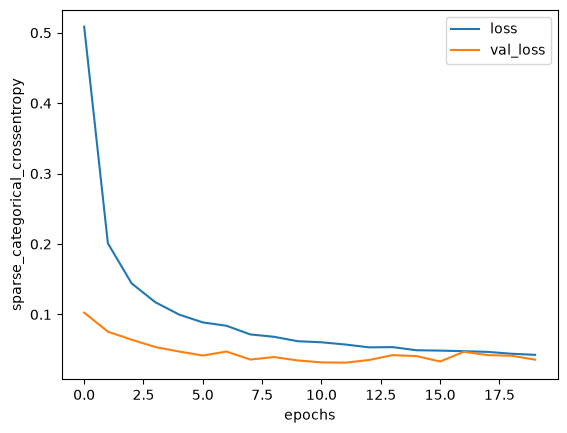

In [85]:
plt.plot(hist['loss'],label='loss')
plt.plot(hist['val_loss'],label='val_loss')
plt.legend()
plt.xlabel('epochs')
plt.ylabel('sparse_categorical_crossentropy')

In [86]:
print(round(min(hist["val_loss"]), 4))
print(round(max(hist["val_accuracy"]), 4))

0.0315
0.9906


In [81]:
submission = pd.DataFrame({
    "ImageId": np.arange(1, len(preds) + 1),   # ou range(len(preds)) selon le format attendu
    "Label": preds
})
submission.to_csv('soumission_CNN_Early.csv',index=False)